---
numbering: false
---

# 5.4. Principal Components Analysis

## Introduction

As we saw in [Chapter 5.3](03-singular-value-decomposition.ipynb), the singular value decomposition of a matrix $X$ into $X = U \Sigma V^T$ can be used to find the best low-rank approximation of $X$, which has applications in image compression, for example. But, hiding in the singular value decomposition is another, more data-driven application: **dimensionality reduction**.

Consider, for example, the dataset below. Each row corresponds to a penguin.

In [7]:
import seaborn as sns
penguins = sns.load_dataset('penguins').dropna()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Each penguin has three categorical features – `species`, `island`, and `sex` – and four numerical features – `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g`. If we restrict our attention to these numerical features, we have a $333 \times 4$ matrix, which we can think of as 333 points in $\mathbb{R}^4$. We, of course, can't visualize in $\mathbb{R}^4$. One solution is to draw scatter plots of all pairs of numerical features. Points are colored by `species`.

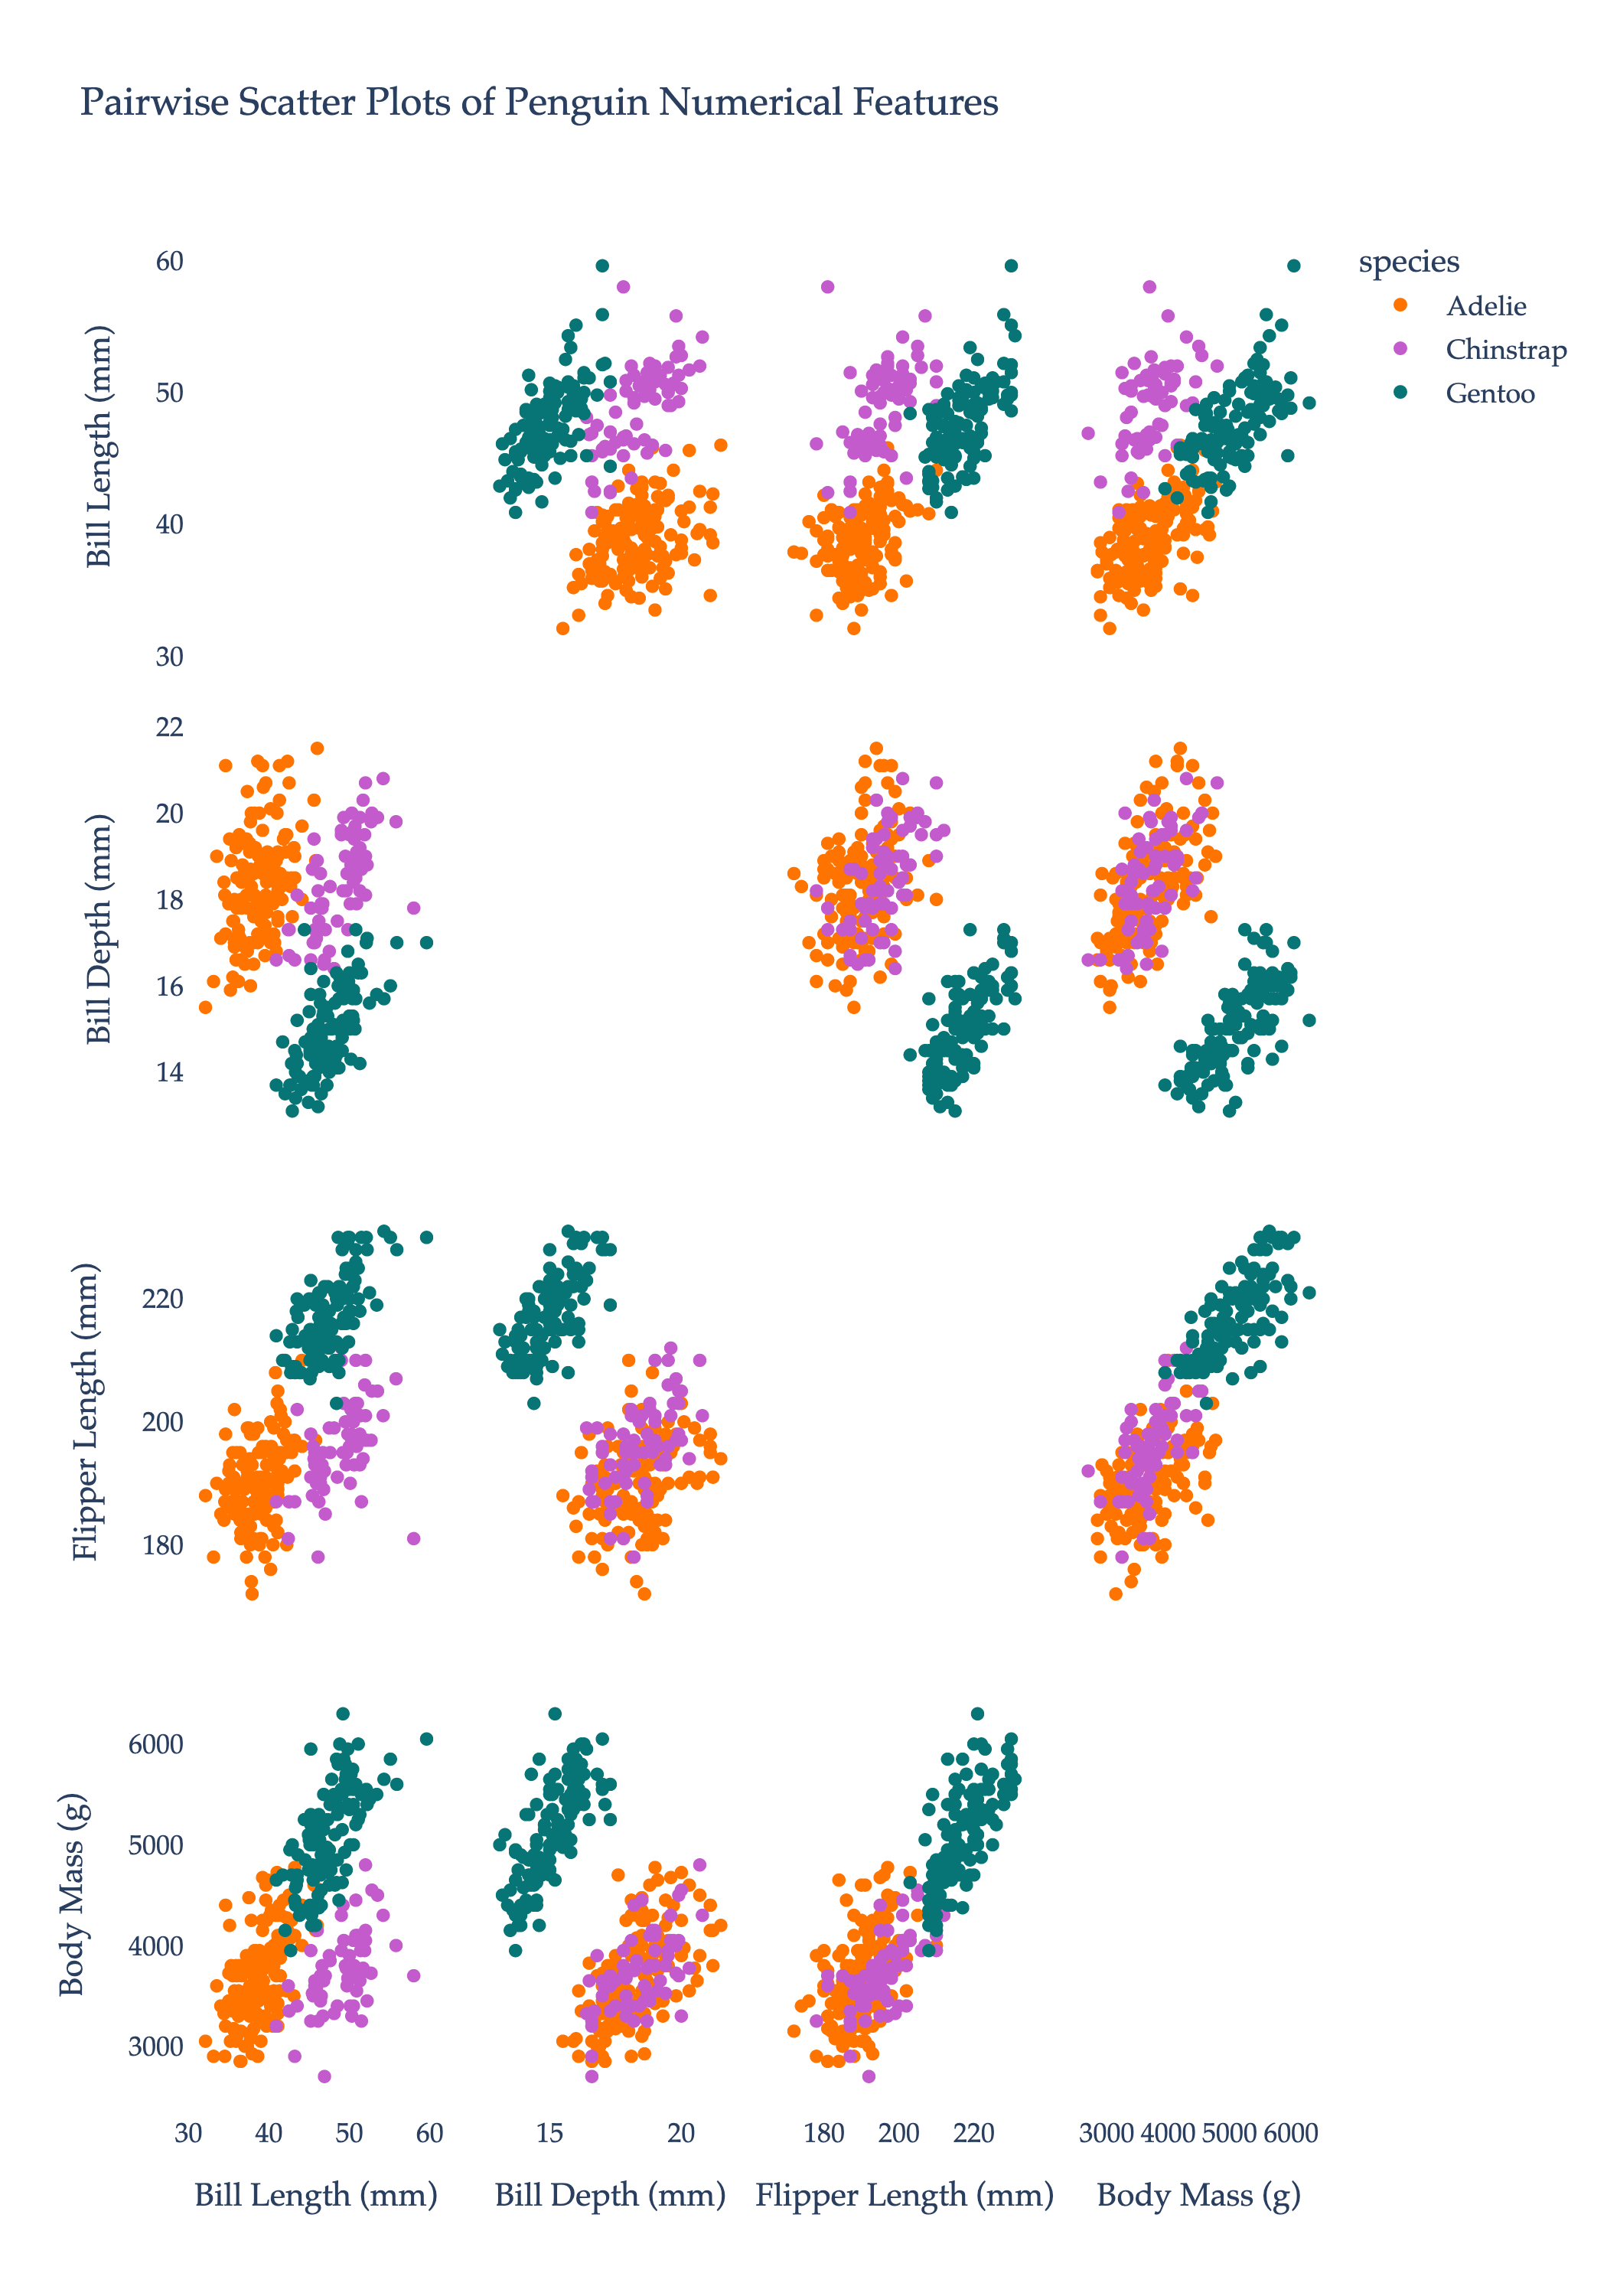

In [14]:
import plotly.express as px

numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Custom color mapping for species
species_color_map = {
    'Adelie': '#ff7400',
    'Chinstrap': '#c45bcc',
    'Gentoo': '#077575'
}

fig = px.scatter_matrix(
    penguins,
    dimensions=numeric_features,
    color='species',
    title='Pairwise Scatter Plots of Penguin Numerical Features',
    labels={
        'bill_length_mm': 'Bill Length (mm)',
        'bill_depth_mm': 'Bill Depth (mm)',
        'flipper_length_mm': 'Flipper Length (mm)',
        'body_mass_g': 'Body Mass (g)'
    },
    color_discrete_map=species_color_map,
)

fig.update_traces(diagonal_visible=False)
fig.update_layout(
    height=1000,
    font_family="Palatino",
    paper_bgcolor="white",
    plot_bgcolor="white",
)

# Set axis background and major/minor gridline colors, and font for axes
# fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="#f0f0f0", zeroline=False, showline=True, linecolor="#ccc", ticks="outside", tickfont_family="Palatino")
# fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="#f0f0f0", zeroline=False, showline=True, linecolor="#ccc", ticks="outside", tickfont_family="Palatino")

fig.show(renderer='png', scale=3)


While we have four features (or "independent" variables) for each penguin, it seems that some of the features are strongly correlated, in the sense that the correlation coefficient

$$r = \frac{1}{n} \sum_{i=1}^n \left( \frac{x_i - \bar{x}}{\sigma_x} \right) \left( \frac{y_i - \bar{y}}{\sigma_y} \right)$$

between them is close to $\pm 1$. (To be clear, the coloring of the points is by `species`, which does not impact the correlations between features.)

In [17]:
penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


For instance, the correlation between `flipper_length_mm` and `body_mass_g` is about $0.87$, which suggests that penguins with longer flippers tend to be heavier. Not only are correlated features redundant, but they can cause interpretability issues – that is, multicollinearity –when using them in a linear regression model, since the resulting optimal parameters $\vec w^*$ will no longer be interpretable. (Remember, in $h(\vec x_i) = \vec w \cdot \text{Aug}(\vec x_i)$, $\vec w^*$ contains the optimal coefficients for each feature, which measure rates of change when the other features are held constant. But if two features are correlated, one can't be held constant without also changing the other.)

**Here's the key idea**: instead of having to work with $d = 4$ features, perhaps we can instead **construct** some number $k < d$ of **new** features that:
1. capture the "most important" information in the dataset,
2. while being **uncorrelated** (i.e. linearly independent) from one another.

I'm not suggesting that we just select some of the original features and drop the others; rather, I'm proposing that we find 1 or 2 new features that are **linear combinations** of the original features. If everything works out correctly, we may be able to **reduce the number of features** we need to deal with, without losing too much information, and without the interpretability issues that come with multicollinearity.

To illustrate what I mean by constructing a new feature, let's suppose we're starting with a 2-dimensional dataset, which we'd like to reduce to 1 dimension. Consider the scatter plot below of `flipper_length_mm` vs. `body_mass_g` (with colors removed).

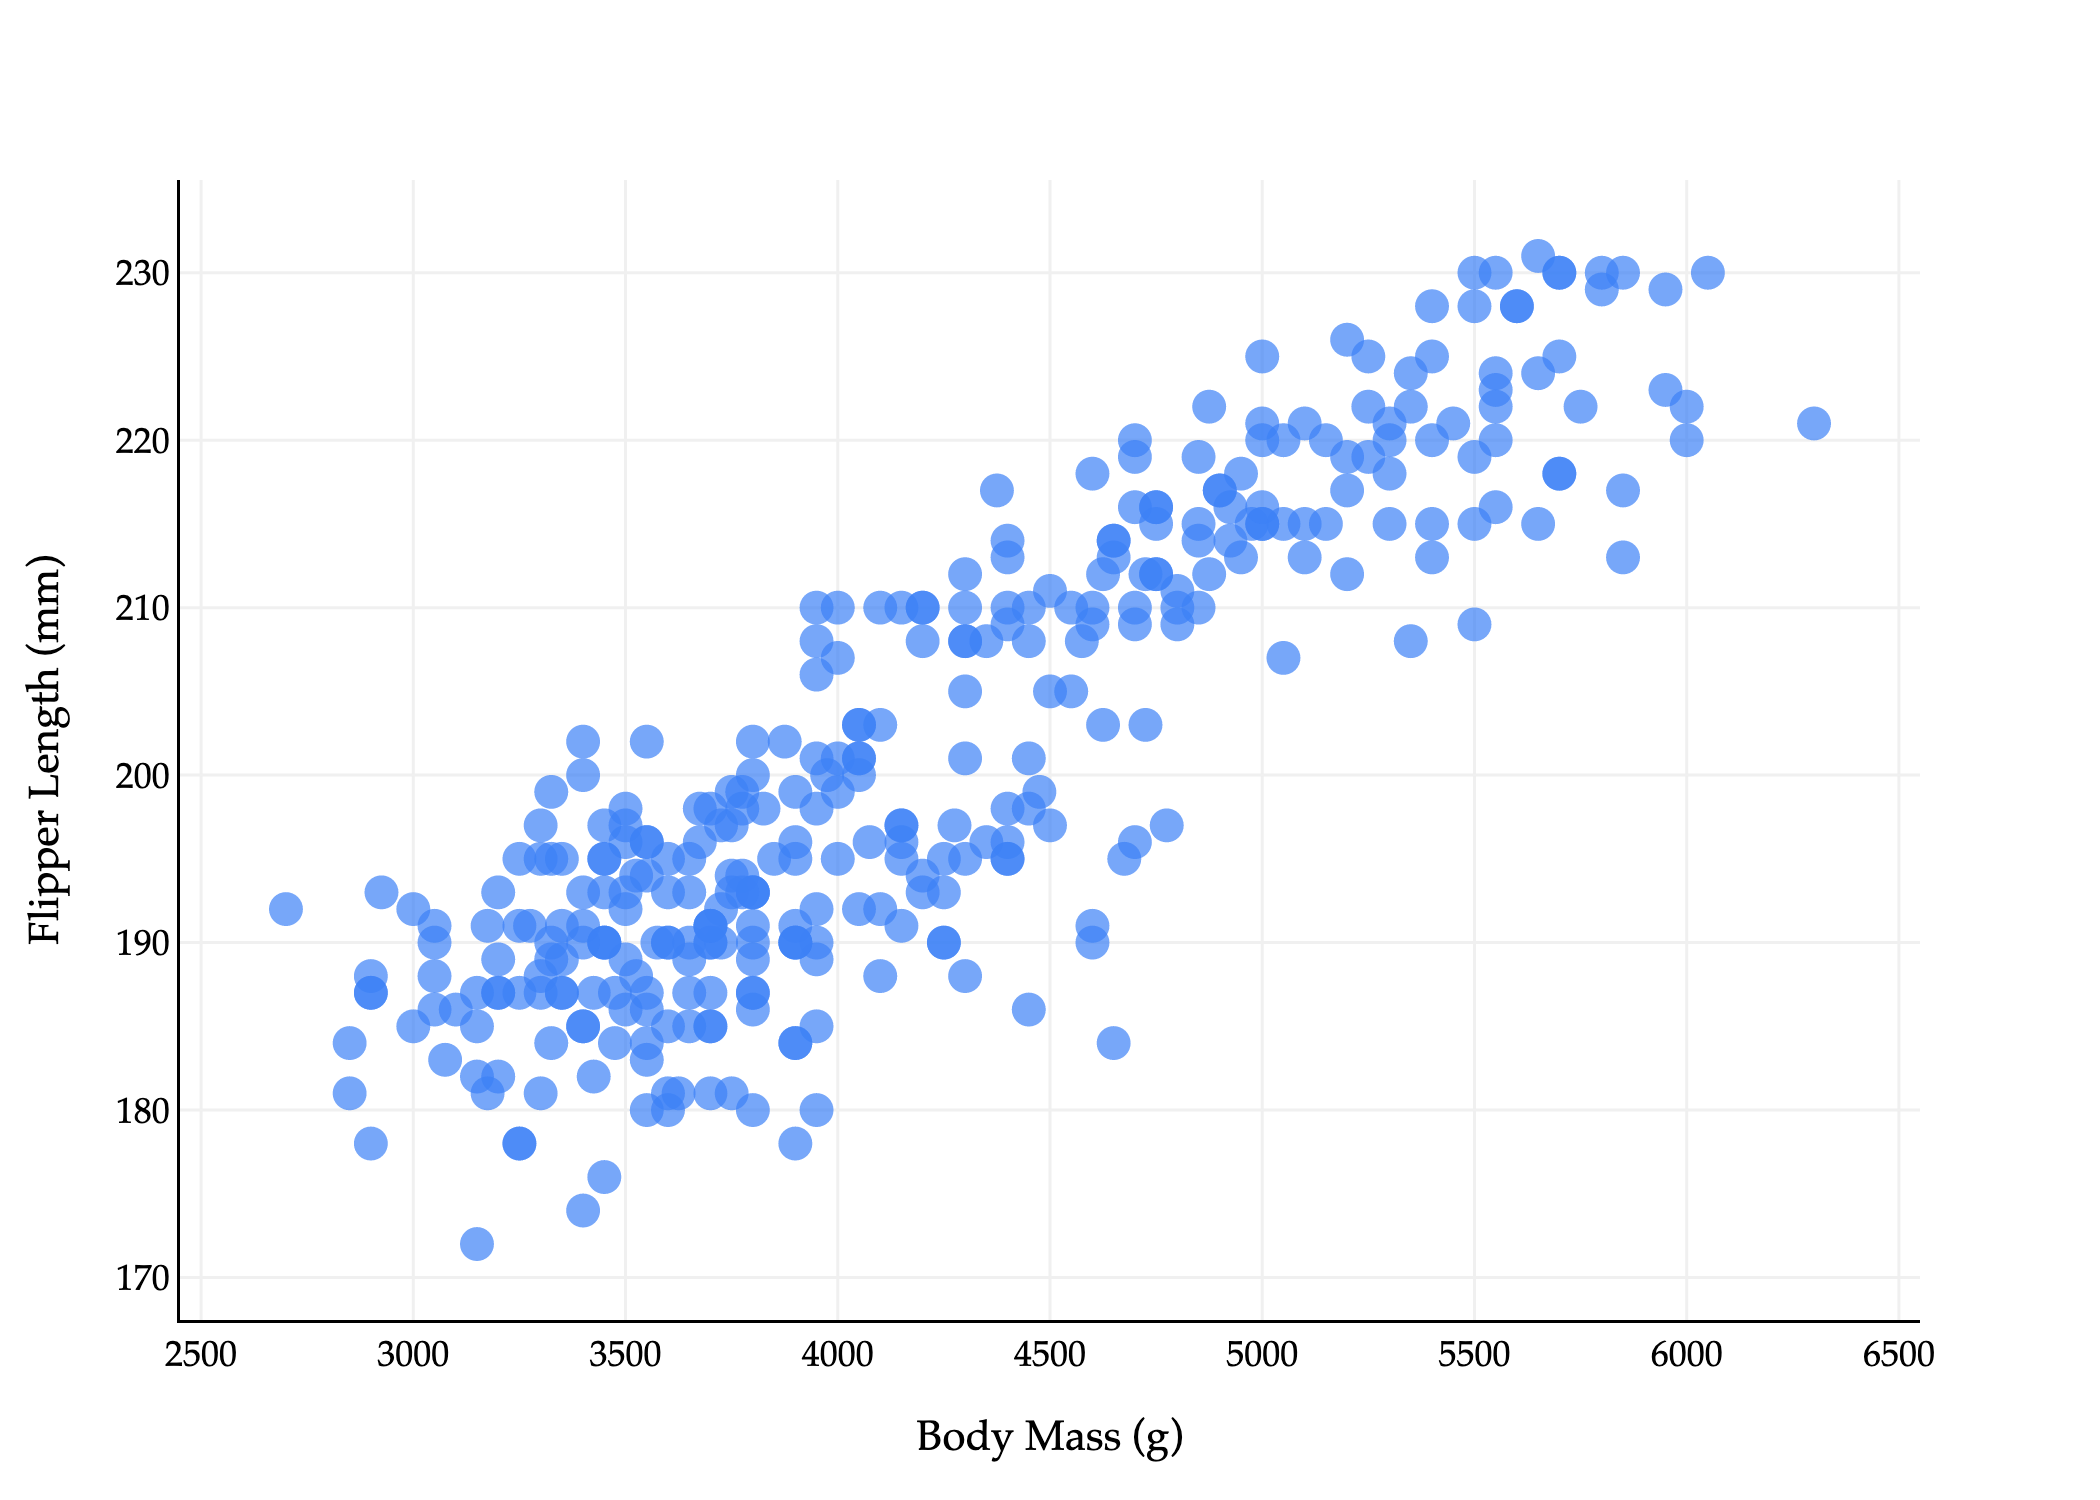

In [51]:
import plotly.express as px
import numpy as np

fig = px.scatter(
    penguins,
    x='body_mass_g',
    y='flipper_length_mm',
    size=np.ones(len(penguins)) * 50,
    size_max=8,
    labels={
        "flipper_length_mm": "Flipper Length (mm)",
        "body_mass_g": "Body Mass (g)"
    }
)
fig.update_xaxes(
    title='Body Mass (g)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Flipper Length (mm)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=3)


Above, each penguin is represented by two numbers, which we can think of as a vector $$\vec x_i = \begin{bmatrix} \text{body mass}_i \\ \text{flipper length}_i \end{bmatrix}$$

The fact that each point is a vector is not immediately intuitive given the plot above: I want you to imagine drawing arrows from the origin to each point.

Now, suppose these vectors $\vec x_i$ are in the rows of a matrix $X$, i.e.

$$X = \begin{bmatrix}
\text{body mass}_1 & \text{flipper length}_1 \\
\text{body mass}_2 & \text{flipper length}_2 \\
\vdots & \vdots \\
\text{body mass}_n & \text{flipper length}_n
\end{bmatrix}$$

Our goal is to construct a single new feature, called a **principal component**,by taking a linear combination of both existing features. 

$$\text{new feature}_i = a \cdot \text{body mass}_i + b \cdot \text{flipper length}_i$$

This is equivalent to approximating this 2-dimensional dataset with a single line. (The equation above is a re-arranged version of $y = mx + b$, where $x$ is `body_mass_g` and $y$ is `flipper_length_mm`.)

**What is the _best_ linear combination of the features, or equivalently, what is the best line to approximate this 2-dimensional dataset?** To make this idea precise, we need to define what we mean by "best". It may be tempting to think that we should find the best-fitting line that predicts `flipper_length_mm` from `body_mass_g`, but that's not quite what we want, since **this is not a prediction problem: it's a representation problem**. Regression lines in the way we've seen them before are fit by minimizing mean squared **vertical** error, $y_i - h(x_i)$, but don't at all capture horizontal errors, i.e. errors in the `body_mass_g` direction here.

So instead, we'd like to find the line such that, for our $n$ vectors (points) $\vec x_1, \ldots, \vec x_n$, the mean squared **distance to the closest vector (point) on the line** is minimized. Crucially, this distance is calculated by computing the norm of the difference between the two vectors. If $\vec p_i$ is the closest vector (point) on the line to $\vec x_i$, then we'd like to minimize

$$\frac{1}{n} \sum_{i=1}^n \lVert \vec x_i - \vec p_i \rVert^2$$

But, as we saw in [Chapter 2.3](../vectors-and-matrices/projection-1), the vector (point) on a line that is closest to another vector (point) $\vec x_i$ is the **orthogonal projection** of $\vec x_i$ onto that line. The resulting error vectors are orthogonal to the line we're projecting on. As such, I'll say that we're looking for the line that minimizes the mean squared **orthogonal projection** error.

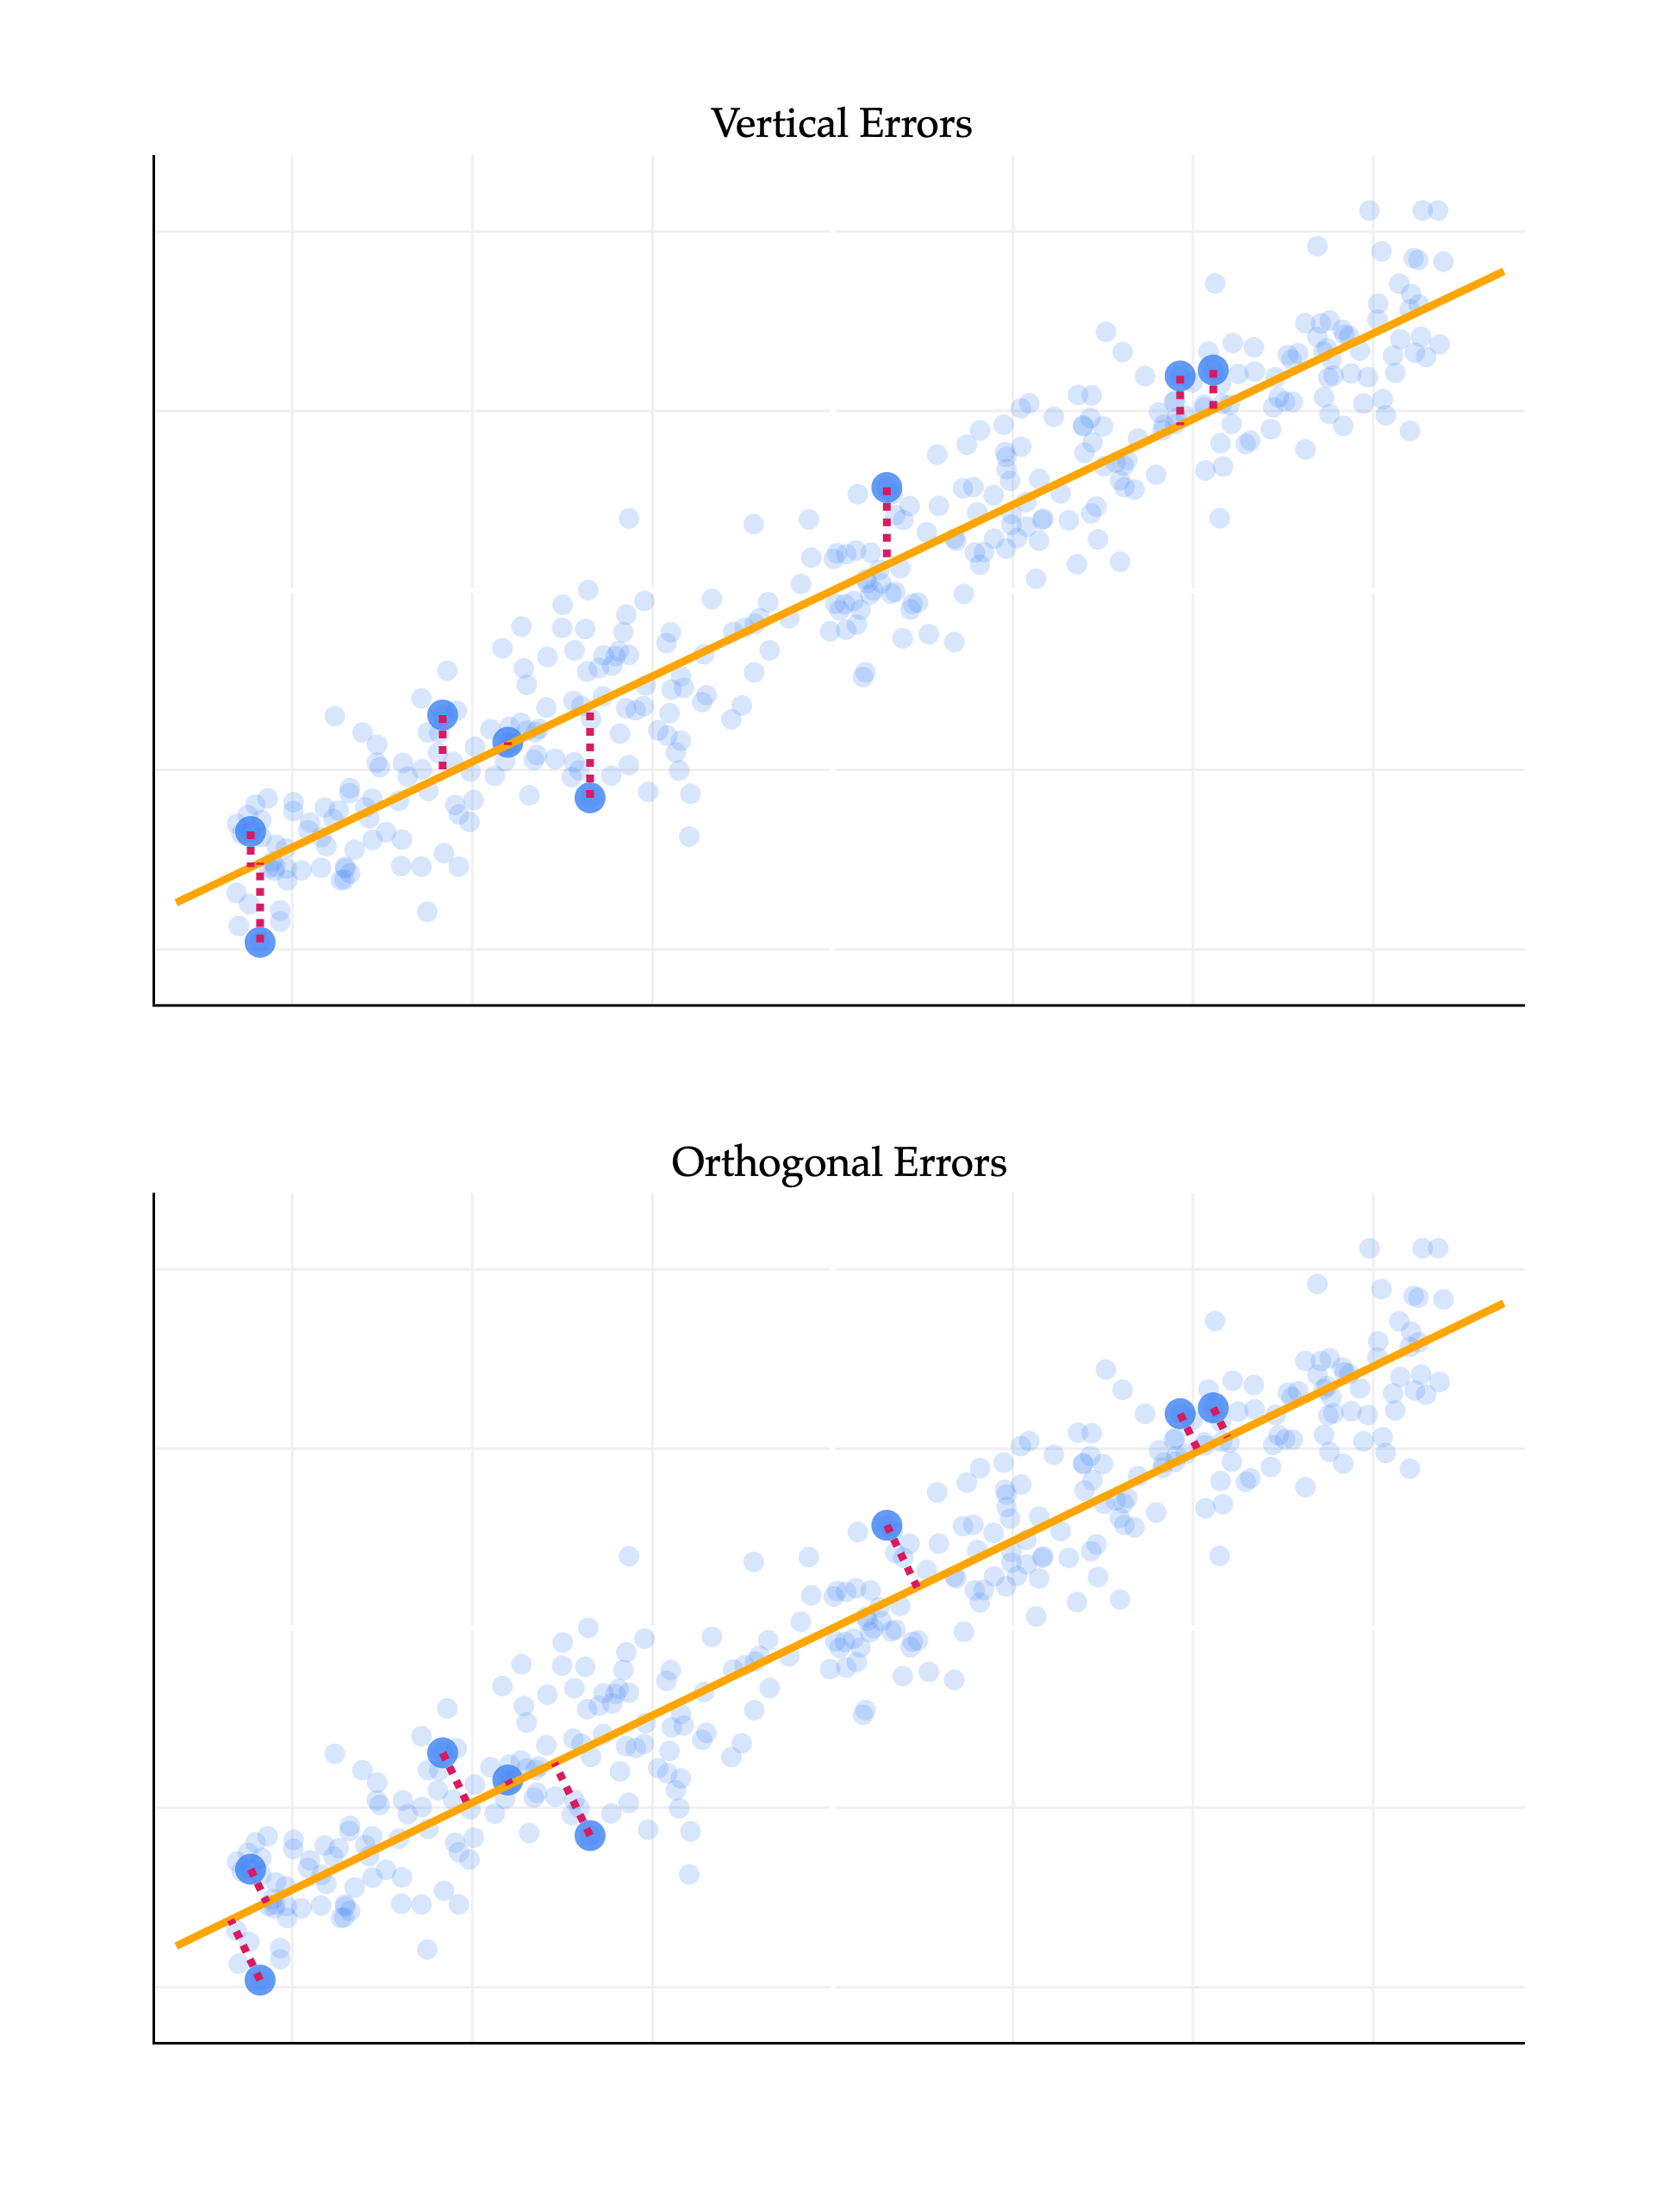

In [99]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

# --- DATA GENERATION (Synthetic Data) ---
# Using synthetic data as the external 'penguins' dataset was inaccessible.
np.random.seed(42)
num_points = 340
body_mass_g = np.random.uniform(2700, 6300, num_points)
m_true = 0.015
c_true = 120
noise = np.random.normal(0, 5, num_points)
flipper_length_mm = m_true * body_mass_g + c_true + noise

df = pd.DataFrame({
    'body_mass_g': body_mass_g,
    'flipper_length_mm': flipper_length_mm
})

# --- STANDARDIZATION ---
# Standardize both columns to mean=0, std=1
for col in ['body_mass_g', 'flipper_length_mm']:
    mean = df[col].mean()
    std = df[col].std()
    df[col + '_std'] = (2 if col == 'body_mass_g' else 1) * (df[col] - mean) / std 

data_2d = df[['body_mass_g_std', 'flipper_length_mm_std']].values

# --- MODEL FITTING on standardized data ---
# Linear Regression (still fit flipper_length_mm_std ~ body_mass_g_std)
lin_reg = LinearRegression()
lin_reg.fit(df[['body_mass_g_std']], df['flipper_length_mm_std'])
m_lr = lin_reg.coef_[0]
c_lr = lin_reg.intercept_

# PCA
pca = PCA(n_components=1)
pca.fit(data_2d)
v1 = pca.components_[0]
mean_data = pca.mean_

# --- SELECTION & RANGE ---
random_indices = np.random.choice(df.index, size=8, replace=False)
random_points = df.iloc[random_indices]

x_min, x_max = df['body_mass_g_std'].min(), df['body_mass_g_std'].max()
x_padding = (x_max - x_min) * 0.05
x_range = np.array([x_min - x_padding, x_max + x_padding])

# --- CALCULATIONS: LINEAR REGRESSION (Top Plot) ---
y_lr_line = m_lr * x_range + c_lr
lr_errors = []
for i in random_indices:
    x_i, y_i = df.loc[i, 'body_mass_g_std'], df.loc[i, 'flipper_length_mm_std']
    y_hat = m_lr * x_i + c_lr
    # Vertical error segment: (x_i, y_i) to (x_i, y_hat)
    lr_errors.append(go.Scatter(
        x=[x_i, x_i, None],
        y=[y_i, y_hat, None],
        mode='lines',
        line=dict(color='#d81a60', width=3, dash='dot'),
        showlegend=False,
        hoverinfo='none'
    ))

# --- CALCULATIONS: PCA (Bottom Plot) ---
# Parametric line points
t_min = (x_range.min() - mean_data[0]) / v1[0]
t_max = (x_range.max() - mean_data[0]) / v1[0]
x_pca_line = np.array([mean_data[0] + t_min * v1[0], mean_data[0] + t_max * v1[0]])
y_pca_line = np.array([mean_data[1] + t_min * v1[1], mean_data[1] + t_max * v1[1]])

pca_errors = []
for idx in random_indices:
    p_i = data_2d[idx]
    projection_scalar = np.dot(p_i - mean_data, v1)
    p_tilde = mean_data + projection_scalar * v1
    # Orthogonal error segment: (p_i) to (p_tilde)
    pca_errors.append(go.Scatter(
        x=[p_i[0], p_tilde[0], None],
        y=[p_i[1], p_tilde[1], None],
        mode='lines',
        line=dict(color='#d81a60', width=3, dash='dot'),
        showlegend=False,
        hoverinfo='none'
    ))

# --- CREATE SUBPLOTS ---
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=False,
    vertical_spacing=0.1,
    subplot_titles=("Vertical Errors", "Orthogonal Errors")
)

## TOP PLOT (ROW 1): LINEAR REGRESSION
# 1. Full Scatter (Low Opacity)
fig.add_trace(go.Scatter(
    x=df['body_mass_g_std'], y=df['flipper_length_mm_std'], mode='markers',
    marker=dict(color="#3D81F6", size=8, opacity=0.2, line_width=0),
    name='All Points (LR)', showlegend=False
), row=1, col=1)

# 2. Selected Scatter (High Opacity)
fig.add_trace(go.Scatter(
    x=random_points['body_mass_g_std'], y=random_points['flipper_length_mm_std'], mode='markers',
    marker=dict(color="#3D81F6", size=12, opacity=0.8, line_width=0),
    name='Selected Points', legendgroup='selected', showlegend=True
), row=1, col=1)

# 3. Line of Best Fit
fig.add_trace(go.Scatter(
    x=x_range, y=y_lr_line, mode='lines',
    line=dict(color='orange', width=3),
    name='Line of Best Fit', legendgroup='lines', showlegend=True
), row=1, col=1)

# 4. Vertical Errors (Placeholder for Legend)
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='#d81a60', width=1.5, dash='dot'),
    name='Errors', legendgroup='errors', showlegend=True
), row=1, col=1)
for error_trace in lr_errors:
    fig.add_trace(error_trace, row=1, col=1)


## BOTTOM PLOT (ROW 2): PCA
# 1. Full Scatter (Low Opacity)
fig.add_trace(go.Scatter(
    x=df['body_mass_g_std'], y=df['flipper_length_mm_std'], mode='markers',
    marker=dict(color="#3D81F6", size=8, opacity=0.2, line_width=0),
    name='All Points (PCA)', showlegend=False
), row=2, col=1)

# 2. Selected Scatter (High Opacity)
fig.add_trace(go.Scatter(
    x=random_points['body_mass_g_std'], y=random_points['flipper_length_mm_std'], mode='markers',
    marker=dict(color="#3D81F6", size=12, opacity=0.8, line_width=0),
    name='Selected Points', legendgroup='selected', showlegend=False
), row=2, col=1)

# 3. First Principal Component Line
fig.add_trace(go.Scatter(
    x=x_pca_line, y=y_pca_line, mode='lines',
    line=dict(color='orange', width=3),
    name='First Principal Component', legendgroup='lines', showlegend=True
), row=2, col=1)

# 4. Orthogonal Errors
for error_trace in pca_errors:
    fig.add_trace(error_trace, row=2, col=1)

# --- APPLY STYLING: Equal aspect ratio for both axes in row 2 ---
common_axis_style = dict(
    title='Flipper Length (standardized)',
    gridcolor='#f0f0f0', showline=True, linecolor="black", linewidth=1,
)
fig.update_yaxes(common_axis_style, row=1, col=1)
fig.update_yaxes(common_axis_style, row=2, col=1)

fig.update_xaxes(
    title='Body Mass (standardized)', gridcolor='#f0f0f0', showline=True, linecolor="black", linewidth=1,
    row=2, col=1
)
fig.update_xaxes(
    gridcolor='#f0f0f0', showline=True, linecolor="black", linewidth=1, row=1, col=1
) # No x-axis title on top plot

# Set aspectmode='equal' for bottom plot only
fig.update_yaxes(
    scaleanchor = "x", scaleratio = 1,
    row=1, col=2,
    title=''
)
fig.update_xaxes(
    constrain='domain',
    row=2, col=1,
)

fig.update_xaxes(
    title='',
    showticklabels=False
)

fig.update_yaxes(
    title='',
    showticklabels=False
)

fig.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=650, height=850,
    font=dict(family="Palatino Linotype, Palatino, serif", color="black"),
    showlegend=False
)

fig.show(renderer='png', scale=3)

The difference between the two lines above is key. The top line reflects the supervised nature of linear regression, where the goal is to make accurate predictions. The bottom line reflects the fact that we're looking for a new representation of the data that captures the most important information. These, in general, are not the same line, since they're chosen to minimize different objective functions. 

Recall from Chapter 1 that **unsupervised learning** is the process of finding structure in unlabeled data, without any specific target variable. This is precisely the problem we're trying to solve here. To further distinguish our current task from the problem of finding regression lines, I'll now refer to finding the line with minimal orthogonal projection error as finding the **best direction**.

:::{tip} Activity 1
Consider the line $\frac{3}{5}x + \frac{4}{5}y = 0$ in $\mathbb{R}^2$. For the point $(1, 1)$,
1. What is the vertical error of projecting $(1, 1)$ onto the line?
2. What is the point on the line that is closest to $(1, 1)$?
3. What is the orthogonal error of projecting $(1, 1)$ onto the line?
:::

---

## Minimizing Orthogonal Error

The first section above told us that our goal is to find the best direction, which is the direction that minimizes the mean squared orthogonal error of projections onto it. How do we find this direction? 

Fortunately, we spent all of [Chapter 2.3](../vectors-and-matrices/projection-1) and [Chapter 2.10](../vectors-and-matrices/projection-2) discussing orthogonal projections. But there, we discussed how to project **one** vector onto the span of one or more other **given** vectors (e.g. projecting the observation vector $\vec y$ onto the span of the columns of a design matrix $X$). That's not quite we're doing here, because here, we don't know which vector we're projecting onto: we're trying to find the **best** vector to project our $n = 333$ other vectors onto!

Suppose that in general, $X$ is an $n \times d$ matrix, whose rows $\vec x_i$ are data points in $\mathbb{R}^d$. (In our current example, $d = 2$, but everything we're studying applies in higher dimensions.) Then,
- The orthogonal projection of $\vec x_i$ onto $\vec v$ is
    $$\vec p_i = \frac{\vec x_i \cdot \vec v}{\vec v \cdot \vec v} \vec v$$
- To keep the algebra slightly simpler, if we assume that $\vec v$ is a unit vector (meaning $\lVert \vec v \rVert = \sqrt{\vec v \cdot \vec v} = 1$), then the orthogonal projection of $\vec x_i$ onto $\vec v$ is
    $$\vec p_i = (\vec x_i \cdot \vec v) \vec v$$
    This is a reasonable choice to make, since unit vectors are typically used to describe directions.
- If $\vec v \in \mathbb{R}^d$, then $\text{span}(\{\vec v\})$ is a line through the origin in $\mathbb{R}^d$.

### Centering the Data

The issue is that our dataset – and most datasets in general, by default – aren't centered at the origin, but the projections $\vec p_i = (\vec x_i \cdot \vec v) \vec v$ all lie on the line through the origin spanned by $\vec v$. So, trying to approximate our dataset using a line through the origin is not a good idea.

So, the solution is to first **center** the data by subtracting the mean of each column from each entry in that column. This gives us a new matrix $\tilde X$.

$$X = \begin{bmatrix} x_1^{(1)} & x_1^{(2)} & \cdots & x_1^{(d)} \\ x_2^{(1)} & x_2^{(2)} & \cdots & x_2^{(d)} \\ \vdots & \vdots & \ddots & \vdots \\ x_n^{(1)} & x_n^{(2)} & \cdots & x_n^{(d)} \end{bmatrix} \rightarrow \tilde X = \begin{bmatrix} x_1^{(1)} - \mu_1 & x_1^{(2)} - \mu_2 & \cdots & x_1^{(d)} - \mu_d \\ x_2^{(1)} - \mu_1 & x_2^{(2)} - \mu_2 & \cdots & x_2^{(d)} - \mu_d \\ \vdots & \vdots & \ddots & \vdots \\ x_n^{(1)} - \mu_1 & x_n^{(2)} - \mu_2 & \cdots & x_n^{(d)} - \mu_d \end{bmatrix}$$

In $\tilde X$, the mean of each column is 0, which means that it's reasonable to approximate the dataset using a line through the origin.

### Finding the Best Direction

Now, $\tilde X$ is the $n \times d$ matrix of centered data, and we're ready to return to our goal of finding the best direction. Let $\tilde x_i \in \mathbb{R}^d$ refer to row $i$ of $\tilde X$. Note that I've dropped the vector symbol on top of $\tilde x_i$, not because it's not a vector, but just because drawing a tilde on top of a vector hat is a little funky: $\vec{\tilde x_i}$.

$$\tilde X = \begin{bmatrix} x_1^{(1)} - \mu_1 & x_1^{(2)} - \mu_2 & \cdots & x_1^{(d)} - \mu_d \\ x_2^{(1)} - \mu_1 & x_2^{(2)} - \mu_2 & \cdots & x_2^{(d)} - \mu_d \\ \vdots & \vdots & \ddots & \vdots \\ x_n^{(1)} - \mu_1 & x_n^{(2)} - \mu_2 & \cdots & x_n^{(d)} - \mu_d \end{bmatrix} = \begin{bmatrix} – & \tilde x_1^T & – \\ – & \tilde x_2^T – \\ & \vdots & \\ – & \tilde x_n^T & – \end{bmatrix}$$

Our goal is to find the **unit vector** $\vec v \in \mathbb{R}^d$ that minimizes the mean squared orthogonal projection error. That is, if the orthogonal projection of $\tilde x_i$ onto $\vec v$ is $\vec p_i$, then we want to find the unit vector $\vec v$ that **minimizes**

$$J(\vec v) = \frac{1}{n}\sum_{i = 1}^n \lVert \tilde x_i - \vec p_i \rVert^2 = \frac{1}{n}\sum_{i = 1}^n \lVert \tilde x_i - (\tilde x_i \cdot \vec v) \vec v \rVert^2$$

I've chosen the letter $J$ since there is no standard notation for this quantity, and because $J$ is a commonly used letter in optimization problems. It's important to note that $J$ is **not** a loss function, nor is it an empirical risk, since it has nothing to do with prediction.

How do we find the unit vector $\vec v$ that minimizes $J(\vec v)$? We can start by expanding the squared norm, using the fact that $\lVert \vec a - \vec b \rVert^2 = \lVert \vec a \rVert^2 - 2 \vec a \cdot \vec b + \lVert \vec b \rVert^2$:

\begin{align*}
J(\vec v) &= \frac{1}{n}\sum_{i = 1}^n \lVert \tilde x_i - (\tilde x_i \cdot \vec v) \vec v \rVert^2 \\
&= \frac{1}{n} \sum_{i=1}^n \left( \lVert \tilde x_i \rVert^2 - 2 \tilde x_i \cdot (\tilde x_i \cdot \vec v) \vec v + \left( (\tilde x_i \cdot \vec v) \vec v \right) \cdot \left( (\tilde x_i \cdot \vec v) \vec v \right) \right) \\
&= \frac{1}{n} \sum_{i=1}^n \left( \lVert \tilde x_i \rVert^2 - 2 \tilde x_i \cdot (\tilde x_i \cdot \vec v) \vec v + (\tilde x_i \cdot \vec v)^2 \underbrace{\vec v \cdot \vec v}_{=1}\right) \\
&= \frac{1}{n} \sum_{i=1}^n \left( \lVert \tilde x_i \rVert^2 - 2 (\tilde x_i \cdot \vec v)^2 + (\tilde x_i \cdot \vec v)^2 \right) \\
&= \frac{1}{n} \sum_{i=1}^n \left( \lVert \tilde x_i \rVert^2 - (\tilde x_i \cdot \vec v)^2 \right) \\
&= \frac{1}{n} \sum_{i = 1}^n \lVert \tilde x_i \rVert^2 - \frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2
\end{align*}

The first term, $\frac{1}{n} \sum_{i = 1}^n \lVert \tilde x_i \rVert^2$, is constant with respect to $\vec v$, meaning we can ignore it for the purposes of minimizing $J(\vec v)$. Our focus, then, is on minimizing the second term, 

$$- \frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2$$

But, since the second term has a negative sign in front of it, minimizing it is equivalent to maximizing its **positive** counterpart,

$$\text{Var}(\vec v) = \frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2$$

---

## Maximizing Variance

We've just stumbled upon a beautiful **duality** – that is, two equivalent ways to think about the same problem. Given a centered $n \times d$ matrix $\tilde X$ with rows $\tilde x_i \in \mathbb{R}^d$, the **most important direction** $\vec v$ is the one that
1. Minimizes the mean squared orthogonal error of projections onto it, $$J(\vec v) = \frac{1}{n} \sum_{i = 1}^n \lVert \tilde x_i - \vec p_i \rVert^2$$
1. Equivalently, maximizes the variance of the values $\tilde x_i \cdot \vec v$, i.e. maximizes

$$\text{Var}(\vec v) = \frac{1}{n} \sum_{i = 1}^n (\tilde x_i \cdot \vec v)^2 = \frac{1}{n} \lVert \tilde X \vec v \rVert^2$$

Where did variance enter the picture? More details to come! While you wait for the notes to be completed, [**here's a great post**](https://stats.stackexchange.com/questions/2691/making-sense-of-principal-component-analysis-eigenvectors-eigenvalues/140579#140579) to reference.

### The Rayleigh Quotient

Recall from [Homework 9, Problem 4](https://eecs245.org/resources/homeworks/hw09/hw09.pdf#page=3) that the **Rayleigh quotient** is defined as

$$f(\vec x) = \frac{\vec x^T A \vec x}{\vec x^T \vec x}$$

for any symmetric $n \times n$ matrix $A$. There, you showed that the gradient of $f$ is given by

$$\nabla f(\vec x) = \frac{2}{\vec x^T \vec x}(A \vec x - f(\vec x) \vec x)$$

How does this relate to our problem? More details to come!

---

:::{attention} The content below is under development, and we will likely only get to it in Thursday's lecture. Thank you for your patience!
:::

## Variance

### The Covariance Matrix

If $\tilde X$ is the centered data matrix, then the covariance matrix $C$ for the dataset is given by

$$C = \frac{1}{n} \tilde X^T \tilde X$$

(When we first saw covariance matrices in an earlier homework, we gave them the variable name $\mathcal{\Sigma}$, but we will avoid this name here to avoid confusion with the $\Sigma$ in the SVD, which we will see shortly.)

What is stored in $C$?
- The diagonal entries in $C$ are dot products of the columns of $\tilde X$ with themselves, divided by $n$. **These are the variances of the columns of $\tilde X$**!
- The off-diagonal entries in $C$ are the dot products of the columns of $\tilde X$ with each other, divided by $n$.

The **total variance** of a dataset, then, is the sum of the diagonal entries in $C$, which is the same as individually computing the variance of each column of $X$.

In [38]:
X_penguins = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
X_penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [47]:
# ddof=0 ensures that we compute the variance with n in the denominator, not n-1.
X_penguins.var(ddof=0).sum()

646654.9577002228

In [49]:
# Subtracts the mean of each column from each entry in that column.
X_penguins_centered = X_penguins - X_penguins.mean(axis=0)

# Computes the covariance matrix.
covar_penguins = (1 / len(X_penguins_centered)) * X_penguins_centered.T @ X_penguins_centered
covar_penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,29.816525,-2.454698,49.907870,2587.828639
bill_depth_mm,-2.454698,3.866243,-15.899359,-746.208506
flipper_length_mm,49.907870,-15.899359,195.851762,9822.605488
body_mass_g,2587.828639,-746.208506,9822.605488,646425.423171


The sum of the diagonal entries of `covar_penguins` is the same as `penguins_features.var(ddof=0).sum()`:

In [50]:
covar_penguins.to_numpy().diagonal().sum()

646654.9577002231